# Data Wrangling — Tiki E-commerce (2 bộ)

Nguồn: [Vietnamese Tiki E-commerce Dataset (Kaggle)](https://www.kaggle.com/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset)

1. `vietnamese_tiki_products_men_shoes.csv` — giày nam  
2. `vietnamese_tiki_products_women_shoes.csv` — giày nữ  

Mục tiêu gốc của bộ dữ liệu: dự đoán `quantity_sold`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? giá trị lạ (`...`, tab, rỗng)?

| Cột | Ý nghĩa |
|---|---|
| `id` | Mã sản phẩm Tiki |
| `name` | Tên sản phẩm |
| `description` | Mô tả (có thể rỗng / `...`) |
| `original_price` | Giá gốc (VND) |
| `price` | Giá hiện tại (VND) |
| `fulfillment_type` | Hình thức giao: `dropship`, `tiki_delivery`, `seller_delivery` |
| `brand` | Thương hiệu (nhiều `OEM`, đôi khi dính tab `\\tOEM`) |
| `review_count` | Số đánh giá |
| `rating_average` | Điểm trung bình (0–5; 0 thường = chưa có đánh giá) |
| `favourite_count` | Số lượt yêu thích |
| `pay_later` | Có trả sau hay không |
| `current_seller` | Tên shop |
| `date_created` | Số ngày từ lần cập nhật |
| `number_of_images` | Số ảnh |
| `vnd_cashback` | Số tiền hoàn (VND) |
| `has_video` | Có video hay không |
| `category` | Danh mục (`Root` = chưa gán danh mục rõ) |
| `quantity_sold` | Tổng số đã bán (biến mục tiêu) |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

path_men = "tiki_data/vietnamese_tiki_products_men_shoes.csv"
path_women = "tiki_data/vietnamese_tiki_products_women_shoes.csv"


In [4]:
df_men = pd.read_csv(path_men) 
df_women = pd.read_csv(path_women)

print("Men shoes:", df_men.shape)  
print("Women shoes:", df_women.shape)

Men shoes: (5745, 19)
Women shoes: (5919, 19)


In [5]:
df_men.head()  
df_women.head()

,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,252071637,"Hộp dép, hộp đựng dép hm - màu cam kich thước ...","Hộp dép, hộp đựng dép hm - màu cam, kíc...",3000,3000,dropship,OEM,0,0.0,0,False,Kho Chuyên Sỉ lẻ Dép,149,7,0,False,Root,0
1,1,208439152,Dép xốp quai ngang đi trong nhà- dép xốp khách...,"Dép xốp quai ngang, đi trong nhà/Khách sạn/Đ...",14200,14200,dropship,OEM,0,0.0,0,False,TT8695,277,6,0,False,Root,0
2,2,105883794,dép tổ ông huyền thoại,Thiết kế đặc biệtChống trơn trượtKhông ngậm nư...,9900,9900,dropship,OEM,3,5.0,0,False,Rumyh Fashion Style,819,4,267,False,Dép quai ngang,8
3,3,252864898,Sen guốc trơn lá lớn_Ảnh thật,"Chào bạn, cảm ơn bạn đã ghé thăm shop ạ...",15000,15000,dropship,OEM,0,0.0,0,False,BOYBON Garden,139,1,0,False,Root,0
4,4,252865522,Cây guốc sao trơn,Cây hawothia guốc sao trơn cây đang con...,13000,13000,dropship,OEM,0,0.0,0,False,BOYBON Garden,139,1,0,False,Root,0


---
# Bộ 1 — Giày nam

## 1. Xử lý giá trị thiếu (Missing Values)

- Chuỗi rỗng / `...` / `"nan"` → `NaN`.
- `fulfillment_type`, `brand`: cột phân loại → **mode**.
- `description`: điền `""` (không xoá dòng).
- `quantity_sold`: biến mục tiêu → `.dropna(subset=["quantity_sold"])`.

In [6]:
df = df_men.copy()  # mẫu: làm việc trên bản sao

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])  # mẫu: xoá cột index thừa



In [7]:
# TODO: xoá trùng theo id rồi reset_index — gợi ý: drop_duplicates(subset=["id"])
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

In [ ]:
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({"nan": np.nan, "": np.nan, "...": np.nan})

df["brand"] = df["brand"].str.replace("\t", "", regex=False)

print(df.isnull().sum())

# mới

df["fulfillment_type"] = df["fulfillment_type"].fillna(
    df["fulfillment_type"].mode(dropna=True)[0]
) 
# TODO:
df["brand"] = df["brand"].fillna(
    df["brand"].mode(dropna=True)[0]
)
# TODO: df["description"] fillna bằng ""
df["description"] = df["description"].fillna("")
# TODO: dropna subset=["quantity_sold"] rồi reset_index
df = df.dropna(subset=["quantity_sold"]).reset_index(drop=True)
# TODO: in lại isnull().sum() sau khi xử lý
df.isnull().sum()


id                    0
name                  0
description         258
original_price        0
price                 0
fulfillment_type      1
brand                 0
review_count          0
rating_average        0
favourite_count       0
pay_later             0
current_seller        0
date_created          0
number_of_images      0
vnd_cashback          0
has_video             0
category              0
quantity_sold         0
dtype: int64


id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    0
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64

## 2. Sửa định dạng dữ liệu (Correct Data Format)

In [11]:
df.dtypes

id                    int64
name                 object
description          object
original_price        int32
price                 int32
fulfillment_type     object
brand                object
review_count          int32
rating_average      float64
favourite_count       int64
pay_later              bool
current_seller       object
date_created          int64
number_of_images      int64
vnd_cashback          int64
has_video              bool
category             object
quantity_sold         int32
dtype: object

In [13]:
df["price"] = df["price"].astype(int)  
 

In [14]:
df[["original_price","quantity_sold","review_count"]] = df[["original_price","quantity_sold","review_count"]].astype(int)

In [15]:
df["rating_average"] = df["rating_average"].astype(float)

In [16]:
# TODO: print dtypes các cột vừa ép
print("dtype", df[["original_price","quantity_sold","review_count","price","rating_average"]].dtypes)

dtype original_price      int32
quantity_sold       int32
review_count        int32
price               int32
rating_average    float64
dtype: object


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Giá đang là **VND**. Đổi sang **nghìn đồng** cho dễ đọc, và tính **% giảm giá** so với giá gốc.

In [22]:
df["price_nghin"] = df["price"] / 1000  # mẫu: VND → nghìn đồng
# TODO: cột original_price_nghin = original_price / 1000
df["original_price_nghin"] = df["original_price"]/1000
# TODO: cột discount_pct = (original_price - price) / original_price * 100
#       dùng np.where(original_price > 0, công_thức, 0)
df["discount_pct"] = np.where( df["original_price"] > 0, (df["original_price"] - df["price"])/df["original_price"] * 100, 0)
df[["price", "price_nghin"]].head()  # mẫu: xem kết quả
# TODO: head thêm original_price và discount_pct
df[["price", "price_nghin","original_price","discount_pct"]].head()

,price,price_nghin,original_price,discount_pct
0,9900,9.900,9900,0.0
1,10000,10.000,10000,0.0
2,9900,9.900,9900,0.0
3,24999,24.999,24999,0.0
4,14200,14.200,14200,0.0


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`price` và `quantity_sold` lệch thang đo rất mạnh → `x / x.max()` về 0–1.

In [17]:
# Chuẩn hóa price về 0–1
df["price_normalized"] = df["price"] / df["price"].max()

# Chuẩn hóa số lượng bán về 0–1
df["quantity_sold_normalized"] = df["quantity_sold"] / df["quantity_sold"].max()

# Chuẩn hóa số lượng đánh giá về 0–1
df["review_count_normalized"] = df["review_count"] / df["review_count"].max()

# Xem thử kết quả
df[[
    "price", "price_normalized",
    "quantity_sold", "quantity_sold_normalized",
    "review_count", "review_count_normalized"
]].head()


,price,price_normalized,quantity_sold,quantity_sold_normalized,review_count,review_count_normalized
0,9900,0.000673,106,0.019525,8,0.008256
1,10000,0.000680,17,0.003131,0,0.000000
2,9900,0.000673,83,0.015288,9,0.009288
3,24999,0.001701,0,0.000000,0,0.000000
4,14200,0.000966,0,0.000000,0,0.000000


## 5. Phân nhóm (Binning)

Chia giá thành Low / Medium / High theo ngưỡng VND thực tế (không dùng min–max đều vì giá max rất lớn, hầu hết sản phẩm sẽ rơi vào Low).

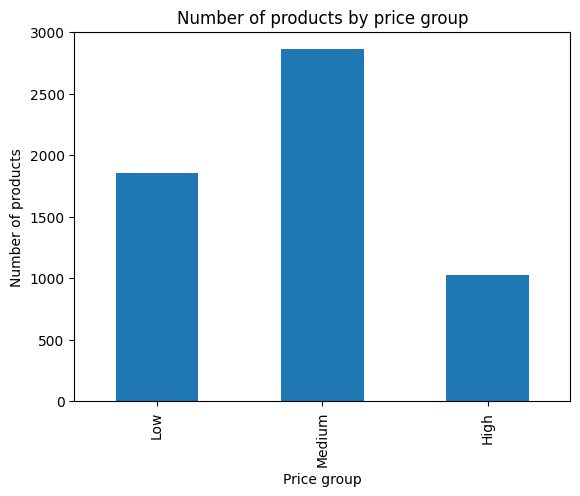

,price,price_binned
0,9900,Low
1,10000,Low
2,9900,Low
3,24999,Low
4,14200,Low


In [18]:
# Chia giá thành 3 nhóm: Low, Medium, High
bins = [0, 100_000, 500_000, df["price"].max() + 1]

df["price_binned"] = pd.cut(
    df["price"],
    bins=bins,
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Đếm và vẽ số sản phẩm theo từng nhóm
df["price_binned"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Price group")
plt.ylabel("Number of products")
plt.title("Number of products by price group")
plt.show()

# Xem giá và nhóm giá tương ứng
df[["price", "price_binned"]].head()


## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`fulfillment_type` (chữ) → mỗi hình thức giao một cột 0/1 bằng `pd.get_dummies()`, rồi xoá cột gốc.

In [19]:
dummy_ff = pd.get_dummies(df["fulfillment_type"], prefix="fulfillment", dtype=int)  # can chuan hoa 0 1
df = pd.concat([df, dummy_ff], axis=1)


df = df.drop(columns=["fulfillment_type"])
df.head()  # check table

,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,has_video,category,quantity_sold,price_normalized,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất Nh...",9900,9900,OEM,8,3.0,0,False,...,False,Root,106,0.000673,0.019525,0.008256,Low,1,0,0
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP SẼ GIA...,10000,10000,OEM,0,0.0,0,False,...,False,Root,17,0.000680,0.003131,0.000000,Low,1,0,0
2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp dép êm ...,9900,9900,OEM,9,3.2,0,False,...,False,Root,83,0.000673,0.015288,0.009288,Low,1,0,0
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠI DÀY/M...,24999,24999,OEM,0,0.0,0,False,...,False,Root,0,0.001701,0.000000,0.000000,Low,1,0,0
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,False,Root,0,0.000966,0.000000,0.000000,Low,1,0,0


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `price`, `quantity_sold` là số
* có cột mới: `price_nghin`, `*_normalized`, `price_binned`, `fulfillment_*`

`index=False` để file không thêm cột index 0,1,2,…


In [20]:
df.to_csv("tiki_men_shoes_clean.csv", index=False)  # cách lưu file

In [21]:
print(df.shape)

# TODO: gán df_men_clean = df để giữ bản sạch bộ nam
df_men_clean = df

(5744, 24)


---
---
# Bộ 2 — Giày nữ

Làm **giống bộ nam**, đổi `df_men` → `df_women`. Copy mẫu ở trên, sửa tên biến. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


In [22]:
df = df_women.copy()  # bắt đầu từ dữ liệu nữ

# TODO: Xóa cột "Unnamed: 0" nếu có, xóa id trùng và reset index
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df = df.drop_duplicates(subset="id").reset_index(drop=True)

# TODO: Xóa khoảng trắng, thay "nan", "" và "..." thành NaN trên các cột object
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({"nan": np.nan, "": np.nan, "...": np.nan})

# TODO: Xóa ký tự tab trong cột brand
df["brand"] = df["brand"].str.replace("\t", "", regex=False)

# TODO: Kiểm tra số lượng missing trước khi xử lý
print(df.isnull().sum())

# TODO: Điền missing bằng mode cho fulfillment_type và brand
df["fulfillment_type"] = df["fulfillment_type"].fillna(
    df["fulfillment_type"].mode()[0]
)

df["brand"] = df["brand"].fillna(
    df["brand"].mode()[0]
)

# TODO: Điền missing của description bằng chuỗi rỗng
df["description"] = df["description"].fillna("")

# TODO: Xóa các dòng bị thiếu quantity_sold và reset index
df = df.dropna(subset=["quantity_sold"]).reset_index(drop=True)

# TODO: Kiểm tra lại số lượng missing sau khi xử lý
print(df.isnull().sum())


id                   0
name                 0
description         59
original_price       0
price                0
fulfillment_type     0
brand                0
review_count         0
rating_average       0
favourite_count      0
pay_later            0
current_seller       0
date_created         0
number_of_images     0
vnd_cashback         0
has_video            0
category             0
quantity_sold        0
dtype: int64
id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    0
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64


price               int32
original_price      int32
quantity_sold       int32
review_count        int32
rating_average    float64
dtype: object
price_binned
Low       2207
Medium    3118
High       592
Name: count, dtype: int64


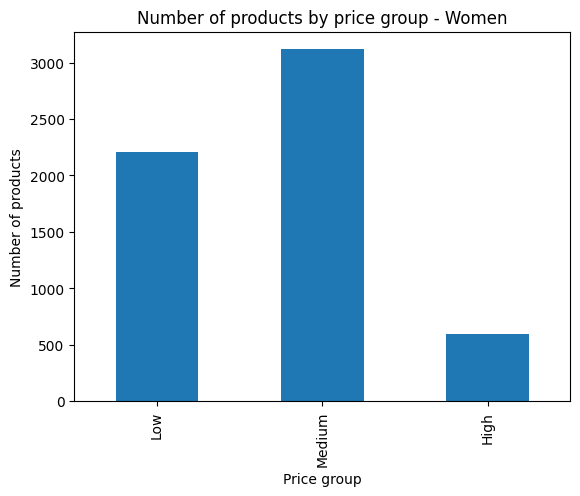

(5917, 27)


,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,price_nghin,original_price_nghin,discount_pct,price_normalized,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,252071637,"Hộp dép, hộp đựng dép hm - màu cam kich thước ...","Hộp dép, hộp đựng dép hm - màu cam, kích thước...",3000,3000,OEM,0,0.0,0,False,...,3.0,3.0,0.0,0.000545,0.000000,0.000000,Low,1,0,0
1,208439152,Dép xốp quai ngang đi trong nhà- dép xốp khách...,"Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,14.2,14.2,0.0,0.002582,0.000000,0.000000,Low,1,0,0
2,105883794,dép tổ ông huyền thoại,Thiết kế đặc biệtChống trơn trượtKhông ngậm nư...,9900,9900,OEM,3,5.0,0,False,...,9.9,9.9,0.0,0.001800,0.000865,0.005155,Low,1,0,0
3,252864898,Sen guốc trơn lá lớn_Ảnh thật,"Chào bạn, cảm ơn bạn đã ghé thăm shop ạ Shop...",15000,15000,OEM,0,0.0,0,False,...,15.0,15.0,0.0,0.002727,0.000000,0.000000,Low,1,0,0
4,252865522,Cây guốc sao trơn,Cây hawothia guốc sao trơn cây đang con Cây ...,13000,13000,OEM,0,0.0,0,False,...,13.0,13.0,0.0,0.002364,0.000000,0.000000,Low,1,0,0


In [23]:
# TODO: Bước 2 — Ép kiểu dữ liệu các cột số
df["price"] = df["price"].astype(int)

df[["original_price", "quantity_sold", "review_count"]] = (
    df[["original_price", "quantity_sold", "review_count"]].astype(int)
)

df["rating_average"] = df["rating_average"].astype(float)

# TODO: Kiểm tra kiểu dữ liệu sau khi ép
print(df[[
    "price", "original_price", "quantity_sold",
    "review_count", "rating_average"
]].dtypes)


# TODO: Bước 3 — Tạo các cột giá mới
df["price_nghin"] = df["price"] / 1000
df["original_price_nghin"] = df["original_price"] / 1000

# TODO: Tính phần trăm giảm giá
df["discount_pct"] = np.where(
    df["original_price"] > 0,
    (df["original_price"] - df["price"]) / df["original_price"] * 100,
    0
)

# TODO: Kiểm tra các cột giá mới
df[[
    "price", "price_nghin",
    "original_price", "original_price_nghin",
    "discount_pct"
]].head()


# TODO: Bước 4 — Chuẩn hóa các cột số về 0–1
for col in ["price", "quantity_sold", "review_count"]:
    df[f"{col}_normalized"] = df[col] / df[col].max()

# TODO: Kiểm tra các cột normalize
df[[
    "price", "price_normalized",
    "quantity_sold", "quantity_sold_normalized",
    "review_count", "review_count_normalized"
]].head()


# TODO: Bước 5 — Chia giá thành 3 nhóm Low / Medium / High
price_bins = [0, 100_000, 500_000, df["price"].max() + 1]

df["price_binned"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# TODO: Đếm số sản phẩm theo từng nhóm giá
print(df["price_binned"].value_counts().sort_index())

# TODO: Vẽ biểu đồ nhóm giá
df["price_binned"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Price group")
plt.ylabel("Number of products")
plt.title("Number of products by price group - Women")
plt.show()

# TODO: Kiểm tra kết quả phân nhóm
df[["price", "price_binned"]].head()


# TODO: Bước 6 — One-hot encoding cho fulfillment_type
dummy_ff = pd.get_dummies(
    df["fulfillment_type"],
    prefix="fulfillment",
    dtype=int
)

# TODO: Gộp các cột dummy vào df
df = pd.concat([df, dummy_ff], axis=1)

# TODO: Xóa cột fulfillment_type gốc
df = df.drop(columns=["fulfillment_type"])

# TODO: Kiểm tra dữ liệu
df.head()


# TODO: Bước 7 — Lưu file dữ liệu nữ
df.to_csv("tiki_women_shoes_clean.csv", index=False)

# TODO: Kiểm tra kích thước và dữ liệu sau khi xử lý
print(df.shape)
df.head()
